<a href="https://colab.research.google.com/github/augustojrr/redes-neurais-UFPI/blob/main/classifica%C3%A7%C3%A3o_MLP_IRIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Atividade 8
##Augusto Cesar de Sousa Passos Junior
##Redes Neurais - UFPI

###Atividade proposta: Uso do MLP para classificação do banco de dados IRIS.
###Pontos requeridos: Resultado final em porcentagem final para 20 repetições (treino/teste), destacando a média e variaância da taxa de acerto no teste. E apresentação do Scatterplot.

# Declaração das funções de ativação que vão ser usadas.

In [ ]:
import numpy as np
# Usando essa biblioteca para facilitar o cálculo com matrizes.

def reLU(x):
  return np.maximum(0,x) # olha cada elemento e mantém os positivos e zera os negativos

def d_reLU(x):
  return np.where(x > 0, 1, 0) # se x > 0 retorna 1, senão retorna 0.

def softmax(x):
    # Subtrai o máximo de cada linha para estabilidade numérica
    # keepdims=True garante que a estrutura da matriz (linhas e colunas) seja mantida
    # axis = -1, garante que vamos somar cada linha individualmente
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))

    # Divide pelo somatório da linha
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

# Incialização das entradas, saídas, pesos e bias.


In [ ]:
import numpy as np
from sklearn.datasets import load_iris

# 1. Inicializando o dataset IRIS

iris = load_iris()
entradas = iris.data # Matriz de entrada (150 amostras x 4 atributos)
saidas = iris.target # Vetor de saídas originais (valores: 0, 1 ou 2)

# 2. Transformando a saída em vetor correspondente -> [1,0,0] = Iris Setosa, por exemplo.

classes = 3 # Numero de classes.
vetor_saida = np.zeros((saidas.size, classes)) # Cria uma matriz de tamanho (quantidade_saidas x numero_classes)
vetor_saida[np.arange(saidas.size),saidas] = 1 # Coloco 1 no lugar correspondente a classe, exemplo [1,0,0] -> Setosa

# 3. Embaralhando os dados de forma aleatória.

indices = np.arange(entradas.shape[0])  # Retorna a quantidade de linhas da matriz de entrada
np.random.seed(42)  # Define uma semente para que o resultado seja sempre o mesmo ao rodar
np.random.shuffle(indices) # Embaralha os elementos de uma lista ou array de forma aleatória diretamente no mesmo local.

inputs = entradas[indices]
outputs = vetor_saida[indices]

# 4. Separando os dados em 70% treino, 15% validação e 15% testes.

total_amostras = entradas.shape[0]
fim_treino = int(0.70 * total_amostras) # 105 amostras de treino
fim_validacao = int(0.15 * total_amostras) # 22 amostras de validacao

# 5. Inicializando as entradas e saídas

entradas_treino, saidas_treino = inputs[:fim_treino], outputs[:fim_treino] # intervalo vai de 0 até 105
entradas_validacao, saidas_validacao = inputs[fim_treino:fim_validacao], outputs[fim_treino:fim_validacao] # intervalo vai de 105 até 127
entradas_teste, saidas_teste = inputs[fim_validacao:], outputs[fim_validacao:] #intervalo vai de 127 até 150

# 6. Inicialização dos Pesos e Bias

W1 = np.random.uniform(-1, 1, (4, 4))  # W1 é uma matriz de pesos, onde os valores dos pesos variam de -1 a 1
B1 = np.random.uniform(-1, 1, (1, 4))  # B1 é uma matriz de Bias, onde os valores do Bias variam de -1 a 1

W2 = np.random.uniform(-1, 1, (4, 3))  # W2 é uma matriz de pesos, onde os valores dos pesos variam de -1 a 1
B2 = np.random.uniform(-1, 1, (1, 3))  # B2 é uma matriz de Bias, onde os valores do Bias variam de -1 a 1

# Forward Pass

In [ ]:
import numpy as np

# Obs: a funcionalidade .dot é importante, pois realiza multiplicação de matrizes, servindo muito bem para o calculo do campo local.

V1 = np.dot(entradas_teste, W1) + B1 # Campo local que vem da soma (entrada*pesos + bias) das 4 entradas.

Y1 = reLU(V1) # Saída dos neurônios da camada escondida que é a entrada dos neurônios da camada de saída, é o valor do campo local V1 passado na funcão de ativação reLU.

V2 = np.dot(Y1, W2) + B2 # Campo local que vem da soma (entrada*pesos + bias) dos valores que vieram da camada oculta

Y_real = softmax(V2) # Saída real vinda dos neurônios de saída, que passaram pela função de ativação Softmax.

# Backpropagation

In [ ]:
import numpy as np

fator_aprendizagem = 0.02

gradiente_V2 = saidas_teste - Y_real # Meu gradiente do campo V2 vai ser simplesmente o erro.

gradiente_V1 = d_reLU(V1) * np.dot(gradiente_V2, W2.T) # Gradiente do campo V1 vai ser a derivada
                                                       # da função de ativação em relação a V1 vezes a matriz que se tem da multiplicação entre Gradiente V2 e transposta de W2.

# EXPLICAÇÃO DO GRADIENTE DE SAÍDA (gradiente_V2):
#
# Por que o gradiente do campo local V2 é simplesmente o ERRO (saidas_treino - Y_real)?
#
# Isso acontece devido ao casamento matemático perfeito entre a função SOFTMAX e a CROSS-ENTROPY.
# Ao aplicarmos a Regra da Cadeia para descobrir como a perda (Loss) varia em relação a V2,
# multiplicamos a derivada da Cross-Entropy pela derivada da Softmax.
#
# Durante essa multiplicação, os termos complexos (exponenciais e divisões do logaritmo)
# se cancelam e se "matam" completamente na álgebra linear. O que sobra dessa simplificação
# é apenas uma operação elementar: a subtração direta entre o gabarito e a previsão da rede.
# ===================================================================================================

# Atualização dos Pesos e Bias

In [ ]:
import numpy as np

# Atualização dos pesos W2 e bias B2
W2 = W2 + (fator_aprendizagem * np.dot(Y1.T,gradiente_V2))
# Usamos np.sum com axis=0 para achatar as linhas em uma única linha (1, 3)
# Ele soma coluna por coluna, para resultar em uma unica linha com 3 colunas.
B2 = B2 + (fator_aprendizagem * np.sum(gradiente_V2, axis=0, keepdims=True))

# Atualização dos pesos W1 e bias B1
W1 = W1 + (fator_aprendizagem * np.dot(entradas_teste.T, gradiente_V1))
B1 = B1 + (fator_aprendizagem * np.sum(gradiente_V1, axis=0, keepdims=True))

# Agora juntando todos os passos para que vejamos a MLP funcionando

## OBS: Na primeira vez rodando o código, não coloquei a normalização das entradas, e isso fez com que a minha rede desse uma variância muito alta, pois como a discrepância das entradas era muito alta, quando multiplicada pelos pesos, alguns neurônios explodiam e outros diminuiam demais, retardando o aprendizado do mesmo e travando a rede.

## Porém, quando normalizamos as entradas, a discrepância diminui bastante, fazendo com os as entradas influenciada pelos pesos tivessem valores parecidos, deixando a rede neural mais estável e assim ir minimizando o erro sem dar saltos tão grandes, a ponto de passar alvo, e assim oscilando em torno do minimo global, que era o que estava acontecendo antes de normalizar as entradas.




In [ ]:
import numpy as np
# Usando essa biblioteca para facilitar o cálculo com matrizes.

def reLU(x):
  return np.maximum(0,x) # olha cada elemento e mantém os positivos e zera os negativos

def d_reLU(x):
  return np.where(x > 0, 1, 0) # se x > 0 retorna 1, senão retorna 0.

def softmax(x):
    # Subtrai o máximo de cada linha para estabilidade numérica
    # keepdims=True garante que a estrutura da matriz (linhas e colunas) seja mantida
    # axis = -1, garante que vamos somar cada linha individualmente
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))

    # Divide pelo somatório da linha
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)


# Incialização das entradas, saídas, pesos e bias. #####################################################################

# Usando essa biblioteca apenas para importar o dataset IRIS.
from sklearn.datasets import load_iris

# 1. Inicializando o dataset IRIS

iris = load_iris()
entradas = iris.data # Matriz de entrada (150 amostras x 4 atributos)
saidas = iris.target # Vetor de saídas originais (valores: 0, 1 ou 2)

# 2. Transformando a saída em vetor correspondente -> [1,0,0] = Iris Setosa, por exemplo.

classes = 3 # Numero de classes.
vetor_saida = np.zeros((saidas.size, classes)) # Cria uma matriz de tamanho (quantidade_saidas x numero_classes)
vetor_saida[np.arange(saidas.size),saidas] = 1 # Coloco 1 no lugar correspondente a classe, exemplo [1,0,0] -> Setosa

# Lista para guardar a acurácia de teste de cada uma das 20 rodadas
historico_acertos_teste = []

# Envelopamento da nossa MLP em 20 reps.

reps = 20

for repeticoes in range(reps):

  # 3. Embaralhando os dados de forma aleatória.

  #np.random.seed(repeticoes)  # Define uma semente para que o resultado seja sempre o mesmo ao rodar

  indices = np.arange(entradas.shape[0])  # Retorna a quantidade de linhas da matriz de entrada
  np.random.shuffle(indices) # Embaralha os elementos de uma lista ou array de forma aleatória diretamente no mesmo local.

  inputs = entradas[indices]
  outputs = vetor_saida[indices]

  # 4. Separando os dados em 70% treino, 15% validação e 15% testes.

  total_amostras = entradas.shape[0]
  # No resumo, ficaram 105 amostras de treino, 22 amostras de validação e 23 amostras de testes.
  fim_treino = int(0.70 * total_amostras) # 105
  fim_validacao =  fim_treino + int(0.15 * total_amostras) # 105 + 22 = 127

  # 5. Inicializando as entradas e saídas

  entradas_treino, saidas_treino = inputs[:fim_treino], outputs[:fim_treino] # intervalo vai de 0 até 105
  entradas_validacao, saidas_validacao = inputs[fim_treino:fim_validacao], outputs[fim_treino:fim_validacao] # intervalo vai de 105 até 127
  entradas_teste, saidas_teste = inputs[fim_validacao:], outputs[fim_validacao:] #intervalo vai de 127 até 150

  # Normalização dos dados de entrada, basicamente os dados de entrada normalizados se dão:

  # entradas_normalizadas = (entradas - média(entradas)) / (desvio padrão)

  # media = valores_de_entradas / entradas
  # desvio padrão = sqrt(variancia)
  # variancia = ((entrada[0] - media)**2 + (entrada[1] - media)**2 + (entrada[2] - media)**2) / n° de fatores

  # o numpy nos ajuda nisso também, fazendo o que foi esclarecido acima, dinamizando
  # do que estamos fazendo.

  media = np.mean(entradas_treino, axis=0)
  desvio = np.std(entradas_treino, axis=0)

  entradas_treino = (entradas_treino - media) / desvio
  entradas_validacao = (entradas_validacao - media) / desvio
  entradas_teste = (entradas_teste - media) / desvio

  # 6. Inicialização dos Pesos e Bias

  W1 = np.random.uniform(-1, 1, (4, 4)) # W1 é uma matriz de pesos, onde os valores dos pesos variam de -1 a 1
  B1 = np.random.uniform(-1, 1, (1, 4)) # B1 é uma matriz de Bias, onde os valores do Bias variam de -1 a 1

  W2 = np.random.uniform(-1, 1, (4, 3)) # W2 é uma matriz de pesos, onde os valores dos pesos variam de -1 a 1
  B2 = np.random.uniform(-1, 1, (1, 3)) # B2 é uma matriz de Bias, onde os valores do Bias variam de -1 a 1

  # Forward Pass e treinamento ##########################################################################################################################################

  epocas = 20000
  fator_aprendizagem = 0.05
  melhor_loss_val = np.inf
  paciencia = int(epocas * 0.02)
  contador = 0
  melhores_pesos = (W1.copy(), B1.copy(), W2.copy(), B2.copy())

  for i in range(epocas):
    # Obs: a funcionalidade .dot é importante, pois realiza multiplicação de matrizes, servindo muito bem para o calculo do campo local.

    # Campo local que vem da soma (entrada*pesos + bias) das 4 entradas.
    V1 = np.dot(entradas_treino, W1) + B1

    # Saída dos neurônios da camada escondida que é a entrada dos neurônios da camada de saída, é o valor do campo local V1 passado na funcão de ativação reLU.
    Y1 = reLU(V1)

    # Campo local que vem da soma (entrada*pesos + bias) dos valores que vieram da camada oculta
    V2 = np.dot(Y1, W2) + B2

    # Saída real vinda dos neurônios de saída, que passaram pela função de ativação Softmax.
    Y_real = softmax(V2)

  # Backpropagation ##########################################################################################################################################

    # Meu gradiente do campo V2 vai ser simplesmente o erro.
    gradiente_V2 = saidas_treino - Y_real

    # Gradiente do campo V1 vai ser a derivada da função de ativação em relação a V1 vezes a matriz que se tem da multiplicação entre Gradiente V2 e transposta de W2.
    gradiente_V1 = d_reLU(V1) * np.dot(gradiente_V2, W2.T)

  # Atualização dos Pesos e Bias

    # Esse "m" é importante, pois ele vai fazer com que o nosso peso seja atualizado pela média do erro,
    # e não pelo erro total obtido, que é muito grande, pois temos 105 amostras somando gradientes, e com
    # isso evitamos a explosão dos gradientes, mantendo a nossa rede neural estável.
    m = entradas_treino.shape[0] # Garantindo que m é 105 (tamanho do treino)

    # Atualização dos pesos W2 e bias B2
    W2 = W2 + ((fator_aprendizagem * np.dot(Y1.T,gradiente_V2)) / m)

    # Usamos np.sum com axis=0 para achatar as linhas em uma única linha (1, 3)
    # Ele soma coluna por coluna, para resultar em uma unica linha com 3 colunas.
    B2 = B2 + ((fator_aprendizagem * np.sum(gradiente_V2, axis=0, keepdims=True))/ m)

    # Atualização dos pesos W1 e bias B1
    W1 = W1 + ((fator_aprendizagem * np.dot(entradas_treino.T, gradiente_V1))/ m)
    B1 = B1 + ((fator_aprendizagem * np.sum(gradiente_V1, axis=0, keepdims=True))/ m)

  # Forward pass validação (sem backpropagation!)
    V1_val = np.dot(entradas_validacao, W1) + B1
    Y1_val = reLU(V1_val)
    V2_val = np.dot(Y1_val, W2) + B2
    Y_val = softmax(V2_val)

    # Calcula acurácia validação
    previsoes_val = np.argmax(Y_val, axis=1)
    gabarito_val = np.argmax(saidas_validacao, axis=1)
    acuracia_val = np.mean(previsoes_val == gabarito_val) * 100

    loss_val_atual = -np.mean(np.sum(saidas_validacao * np.log(Y_val + 1e-8), axis=1))

    if loss_val_atual < melhor_loss_val - 1e-4:  # houve melhora real
        melhor_loss_val = loss_val_atual
        contador = 0
        melhores_pesos = (W1.copy(), B1.copy(), W2.copy(), B2.copy())  # salva o melhor estado
    else:
        contador += 1
        if contador >= paciencia:
            print(f"  Early stopping na época {i} | Melhor loss val: {melhor_loss_val:.4f}")
            break

  W1, B1, W2, B2 = melhores_pesos

  print(f"Repetição {repeticoes+1} - Acurácia de validação: {acuracia_val:.2f}%")

  # --- FIM DO TREINO DA RODADA: HORA DO TESTE FINAL ---
  # Rodamos o Forward Pass nos dados de TESTE usando os pesos finais que a rede aprendeu

  V1_teste = np.dot(entradas_teste, W1) + B1
  Y1_teste = reLU(V1_teste)
  V2_teste = np.dot(Y1_teste, W2) + B2
  Y_teste = softmax(V2_teste)

  # np.argmax descobre qual classe teve a maior probabilidade (ex: transforma [0.1, 0.7, 0.2] em classe 1)
  previsoes_teste = np.argmax(Y_teste, axis=1)
  gabarito_teste = np.argmax(saidas_teste, axis=1)

  # Calcula a taxa de acerto (Acurácia) em porcentagem
  acuracia_teste = np.mean(previsoes_teste == gabarito_teste) * 100
  historico_acertos_teste.append(acuracia_teste)

  print(f"Repetição {repeticoes+1:02d}/{reps} concluída. Taxa de acerto no Teste: {acuracia_teste:.2f}%")


# --- EXIBIÇÃO DOS RESULTADOS ESTATÍSTICOS SOLICITADOS ---
print("\n" + "="*50)
print("             RELATÓRIO ESTATÍSTICO FINAL            ")
print("="*50)

# Transforma em array NumPy para usar as funções estatísticas prontas
historico_acertos_teste = np.array(historico_acertos_teste)

# Calcula a média e a variância dos acertos
media_final = np.mean(historico_acertos_teste)
variancia_final = np.var(historico_acertos_teste)

print(f"Média da Taxa de Acerto: {media_final:.2f}%")
print(f"Variância dos Acertos:   {variancia_final:.4f}")
print("="*50)

# --- Gerando a Matriz de Confusão ---
print(f"\n--- Matriz de Confusão da Repetição {repeticoes+1} ---")

# Criamos a lista com o nome textual das classes
nomes_classes = ['Iris Setosa', 'Iris Versicolor', 'Iris Virginica']
n_classes = len(nomes_classes)

# Inicializa a matriz preenchida com zeros usando Numpy
matriz_confusao = np.zeros((n_classes, n_classes), dtype=int)

# Preenche cruzando a posição do gabarito (linha) com a previsão (coluna)
for real, previsto in zip(gabarito_teste, previsoes_teste):
    matriz_confusao[real, previsto] += 1

# --- Exibindo a Matriz formatada e alinhada ---
# Cabeçalho das colunas (Predições)
print(f"{'Real / Previsto':<18}", end="")
for classe in nomes_classes:
    print(f"{classe:>18}", end="")
print("\n" + "-" * (18 + 18 * n_classes))

# Linhas da matriz (Valores Reais)
for i, classe_real in enumerate(nomes_classes):
    print(f"{classe_real:<18}", end="")
    for j in range(n_classes):
        print(f"{matriz_confusao[i, j]:>18}", end="")
    print()
print("="*50)

  Early stopping na época 2395 | Melhor loss val: 0.0600
Repetição 1 - Acurácia de validação: 100.00%
Repetição 01/20 concluída. Taxa de acerto no Teste: 95.65%
  Early stopping na época 1934 | Melhor loss val: 0.1672
Repetição 2 - Acurácia de validação: 90.91%
Repetição 02/20 concluída. Taxa de acerto no Teste: 95.65%
  Early stopping na época 3315 | Melhor loss val: 0.1236
Repetição 3 - Acurácia de validação: 90.91%
Repetição 03/20 concluída. Taxa de acerto no Teste: 100.00%
  Early stopping na época 2250 | Melhor loss val: 0.0832
Repetição 4 - Acurácia de validação: 95.45%
Repetição 04/20 concluída. Taxa de acerto no Teste: 95.65%
  Early stopping na época 1925 | Melhor loss val: 0.0748
Repetição 5 - Acurácia de validação: 95.45%
Repetição 05/20 concluída. Taxa de acerto no Teste: 95.65%
  Early stopping na época 9897 | Melhor loss val: 0.0020
Repetição 6 - Acurácia de validação: 100.00%
Repetição 06/20 concluída. Taxa de acerto no Teste: 86.96%
  Early stopping na época 14676 | Mel

# Apresentação do Scatterplot

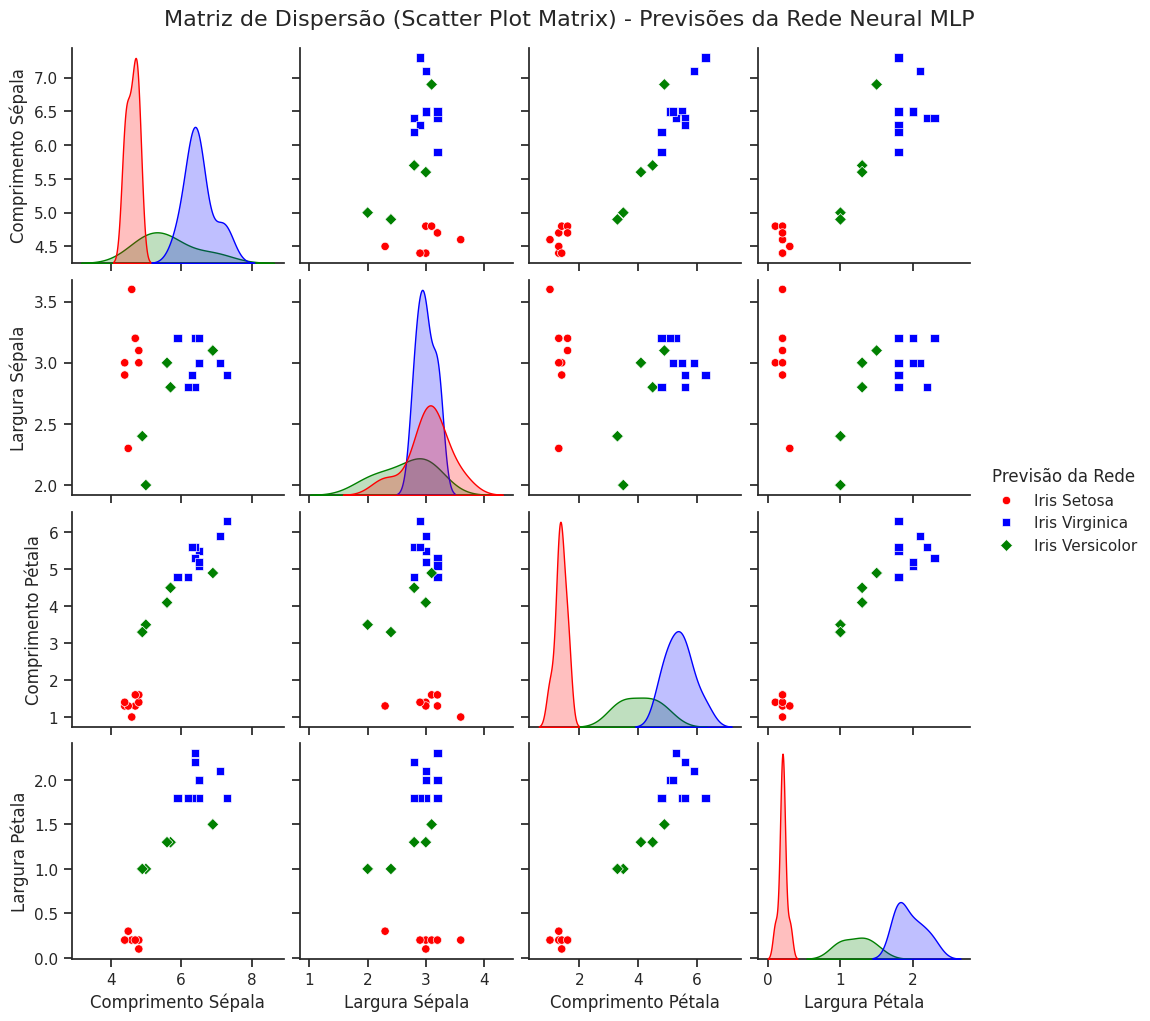

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- GERANDO A MATRIZ DE GRÁFICOS (PAIRPLOT) ---

# 1. Pegamos as características das flores do conjunto de teste original (antes da normalização para os dados baterem com o Iris real)
# Nota: Como reescrevemos a variável 'entradas_teste' com a normalização, o ideal é usar os dados originais não-normalizados
# correspondentes aos mesmos índices de teste para o gráfico ficar com a escala real (cm).
entradas_teste_originais = inputs[fim_validacao:]

# 2. Criamos um DataFrame do Pandas para organizar os dados para o Seaborn
nomes_atributos = ['Comprimento Sépala', 'Largura Sépala', 'Comprimento Pétala', 'Largura Pétala']
df_teste = pd.DataFrame(entradas_teste_originais, columns=nomes_atributos)

# 3. Mapeamos as previsões numéricas que a sua rede gerou (0, 1, 2) para os nomes reais das flores
nomes_classes = ['Iris Setosa', 'Iris Versicolor', 'Iris Virginica']
previsoes_nomes = [nomes_classes[p] for p in previsoes_teste]

# Adicionamos a coluna de previsões da sua rede no DataFrame
df_teste['Previsão da Rede'] = previsoes_nomes

# 4. Definimos as cores para bater com o padrão solicitado (Setosa=Vermelho, Versicolor=Verde, Virginica=Azul)
paleta_cores = {'Iris Setosa': 'red', 'Iris Versicolor': 'green', 'Iris Virginica': 'blue'}

# 5. Criamos o gráfico de matriz de dispersão cruzada
sns.set_theme(style="ticks")
grid = sns.pairplot(
    df_teste,
    hue='Previsão da Rede',
    palette=paleta_cores,
    markers=["o", "s", "D"], # Formatos diferentes para cada flor (Bolinha, Quadrado, Losango)
    corner=False # Mantém a matriz completa (quadrada) igual à imagem da sua atividade
)

# Adiciona um título geral ao topo do gráfico
grid.fig.suptitle("Matriz de Dispersão (Scatter Plot Matrix) - Previsões da Rede Neural MLP", y=1.02, fontsize=16)

# Exibe o gráfico na tela
plt.show()

#Interpretação do gráfico gerado:

### Analisando o nosso gráfico scatterplot, quando comparamos comprimentos e larguras das sépalas e pétalas, vemos que na maioria dos gráficos a classe das iris estão sempre próximas umas as outras, como pode ser observado, a única que consegue se distoar minimamente bem das outras por suas caracteristicas é a iris setosa, a virginica e versicolor são bem parecidas. Mas, quando olhamos a comparação da Largura das Petalas em relação ao comprimento da Pétala, largura e comprimento da Sépala, observamos que as 3 classes se diferem melhor, o que facilita a classificação da nossa rede neural, pois pensando em uma fronteira de decisão, a nossa rede conseguirá fazer 2 fronteiras de decisões bem definidas, que separam as 3 classes e assim conseguir classificar as Iris com um nível de acerto alto.

#Conclusão:

### A conclusão que temos é que a MLP se saiu muito bem na classificação do banco de dados IRIS, com uma taxa de acerto média de 94,35%, e uma variância praticamente de 19, o que é um resultado satisfatório, com uma boa taxa de acerto e uma variância pequena, mostrando a robustez do nosso modelo, tendo em vista que o banco de dados IRIS é um banco pequeno, se compararmos com outros bancos de dados. É importante ressaltar também, a importância da normalização dos dados de entrada, pois sem esse ajuste, nosso modelo ficava "travado", fazendo com que a taxa de acerto médio fosse bem menor do que o esperado, e a variância fosse muito maior do que a obtida no resultado final.